In [2]:
import torch
import torch.nn as nn
import snntorch as snn
import numpy as np
from snntorch.import_nir import import_from_nir
import nir

In [3]:
graph = nir.read("cnn_sinabs.nir")
graph.nodes.keys()

dict_keys(['0', '1', '10', '11', '12', '2', '3', '4', '5', '6', '7', '8', '9', 'input', 'output'])

In [4]:
net = import_from_nir(graph)

replace rnn subgraph with nirgraph


In [5]:
net

GraphExecutor(
  (0): Conv2d(2, 16, kernel_size=(5, 5), stride=(2, 2), padding=(1, 1))
  (1): Leaky()
  (10): Leaky()
  (11): Linear(in_features=256, out_features=10, bias=True)
  (12): Leaky()
  (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): Leaky()
  (4): AvgPool2d(kernel_size=(2, 2), stride=(2, 2), padding=(0, 0))
  (5): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): Leaky()
  (7): AvgPool2d(kernel_size=(2, 2), stride=(2, 2), padding=(0, 0))
  (8): Flatten(start_dim=0, end_dim=-1)
  (9): Linear(in_features=128, out_features=256, bias=True)
  (input): Identity()
  (output): Identity()
)

## 1) Spike activity of the hidden layer

In [6]:
inp_data = torch.from_numpy(np.load("cnn_numbers.npy")).float()
inp_data.shape

torch.Size([300, 10, 2, 34, 34])

In [7]:
modules = [e.elem for e in net.get_execution_order()]

In [8]:
# init all I&F neurons
mem_dict = {}
for idx, module in enumerate(modules):
  if isinstance(module, snn.Leaky):
    mem_dict[idx] = module.init_leaky()

out = []
act = []
for t in range(inp_data.shape[0]):
  x = inp_data[t]
  spklayer = None
  for idx, module in enumerate(modules):
    if isinstance(module, nn.Flatten):
      x = x.flatten(1, -1)
    elif isinstance(module, snn.Leaky):
      x, mem_dict[idx] = module(x, mem_dict[idx])
      if spklayer is None:
        spklayer = x.detach().numpy()
    else:
      x = module(x)
  out.append(x)
  act.append(spklayer)
out = torch.stack(out).detach()

# Load the dataset used to measure the accuracy of the sinabs SCNN

In [9]:
from nmnist import NMNISTFrames, NMNISTRaster

batch_size = 64
raster_dataset = NMNISTRaster(save_to='data', batch_size=batch_size, n_time_bins=20, precision=32, num_workers=0)
raster_dataset.setup()
dataloader = raster_dataset.test_dataloader()

/home/rcarlos/Documentos/SNN/Renan/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
import numpy as np
import torch
import os

def export_dataloader_to_txt(dataloader, filename_data, filename_targets, max_samples=None):
    """
    Exporta dados de um DataLoader para um arquivo de texto no formato de eventos e os targets para outro arquivo.
    
    Args:
        dataloader: DataLoader do PyTorch contendo os dados.
        filename_data (str): Caminho do arquivo de saída para os dados (eventos).
        filename_targets (str): Caminho do arquivo de saída para os targets (labels).
        max_samples (int, optional): Número máximo de amostras a exportar. Se None, exporta todas.
        
    Formato das colunas no arquivo TXT de dados:
        type amplitude timestamp time_step batch channel height width
        
    Tipos de evento:
        0: Spike convencional
        1: Fim de passo temporal (TYPE_END_STEP)
        2: Fim de amostra/batch (TYPE_END_BATCH)
    """
    sample_count = 0
    
    with open(filename_data, 'w') as f_data, open(filename_targets, 'w') as f_targets:
        for batch_idx, (data, labels) in enumerate(dataloader):
            # Converte para numpy se necessário
            if hasattr(data, 'cpu'):
                data = data.cpu().numpy()
            elif not isinstance(data, np.ndarray):
                data = np.array(data)
                
            if hasattr(labels, 'cpu'):
                labels = labels.cpu().numpy()
            elif not isinstance(labels, np.ndarray):
                labels = np.array(labels)
                
            # Assume shape: (batch_size, time_steps, channels, height, width)
            # Se o shape for diferente, ajuste conforme necessário
            if data.ndim == 4:  # Se for (batch, channels, height, width)
                data = np.expand_dims(data, 1)  # Adiciona dimensão temporal
            
            batch_size = data.shape[0]
            num_time_steps = data.shape[1]
            
            # Determina o tamanho real do batch considerando max_samples
            actual_batch_size = batch_size
            if max_samples is not None and sample_count + batch_size > max_samples:
                actual_batch_size = max_samples - sample_count
                
            if actual_batch_size <= 0:
                break

            # Itera sobre cada amostra do batch
            for b in range(actual_batch_size):
                batch_global = sample_count + b
                
                # Escreve o target para esta amostra
                if labels.ndim > 0 and len(labels) > b:
                    label = labels[b]
                elif labels.ndim == 0:
                    label = labels
                else:
                    label = labels[0] # Fallback
                f_targets.write(f"{label}\n")
                
                # Itera sobre cada passo temporal
                for t in range(num_time_steps):
                    # slice_data shape: (channels, height, width)
                    slice_data = data[b, t]
                    
                    # Encontra coordenadas (c, h, w) dos spikes
                    c_indices, h_indices, w_indices = np.nonzero(slice_data)
                    
                    # Itera sobre os spikes encontrados neste passo de tempo
                    for i in range(len(c_indices)):
                        c = c_indices[i]
                        h = h_indices[i]
                        w = w_indices[i]
                        amplitude = slice_data[c, h, w]
                        
                        # Escreve pacote TYPE_SPIKE (0) apenas se amplitude != 0
                        if amplitude != 0:
                            f_data.write(f"0 {amplitude} {t} {t} {batch_global} {c} {h} {w}\n")
                    
                    # Ao final de todos os spikes do passo t, escreve TYPE_END_STEP (1) ou TYPE_END_BATCH (2)
                    if t < num_time_steps - 1:
                        f_data.write(f"1 0 {t} {t} {batch_global} 0 0 0\n")
                    else:
                        f_data.write(f"2 0 {t} {t} {batch_global} 0 0 0\n")
            
            prev_count = sample_count
            sample_count += actual_batch_size
            
            if (prev_count // 100) < (sample_count // 100):
                print(f"Processadas {sample_count} amostras...")
                
            if max_samples is not None and sample_count >= max_samples:
                break
    
    print(f"Arquivos gerados com sucesso: {filename_data} e {filename_targets}")
    print(f"Total de amostras exportadas: {sample_count}")


# Configuração dos caminhos
output_dir = "n-mnist_test_20_steps_txt"
os.makedirs(output_dir, exist_ok=True)

events_file = os.path.join(output_dir, "nmnist_test_events_full.txt")
targets_file = os.path.join(output_dir, "nmnist_test_targets_full.txt")

# Exemplo de uso com o dataloader existente
# Certifique-se de que o dataloader está definido antes de executar
# export_dataloader_to_txt(dataloader, os.path.join(output_dir, "nmnist_test_events.txt"), os.path.join(output_dir, "nmnist_test_targets.txt"), max_samples=1000)

# Se quiser exportar todas as amostras do test_dl:
export_dataloader_to_txt(dataloader, events_file, targets_file)

Processadas 128 amostras...
Processadas 256 amostras...
Processadas 320 amostras...
Processadas 448 amostras...
Processadas 512 amostras...
Processadas 640 amostras...
Processadas 704 amostras...
Processadas 832 amostras...
Processadas 960 amostras...
Processadas 1024 amostras...
Processadas 1152 amostras...
Processadas 1216 amostras...
Processadas 1344 amostras...
Processadas 1408 amostras...
Processadas 1536 amostras...
Processadas 1600 amostras...
Processadas 1728 amostras...
Processadas 1856 amostras...
Processadas 1920 amostras...
Processadas 2048 amostras...
Processadas 2112 amostras...
Processadas 2240 amostras...
Processadas 2304 amostras...
Processadas 2432 amostras...
Processadas 2560 amostras...
Processadas 2624 amostras...
Processadas 2752 amostras...
Processadas 2816 amostras...
Processadas 2944 amostras...
Processadas 3008 amostras...
Processadas 3136 amostras...
Processadas 3200 amostras...
Processadas 3328 amostras...
Processadas 3456 amostras...
Processadas 3520 amostr

## 2) Accuracy on the whole dataset

In [ ]:
import tonic
import tqdm

In [ ]:
# bs = 128
# collate = tonic.collation.PadTensors(batch_first=False)
# to_frame = tonic.transforms.ToFrame(
#     sensor_size=tonic.datasets.NMNIST.sensor_size, time_window=1e3
# )
# test_ds = tonic.datasets.NMNIST("./nmnist", transform=to_frame, train=False)
# test_dl = torch.utils.data.DataLoader(
#     test_ds, shuffle=True, batch_size=bs, collate_fn=collate
# )

# accuracies = []
# pbar = tqdm.tqdm(total=len(test_dl), desc="Processing", position=0, leave=True)
# for idx, (x, y) in enumerate(test_dl):
#     # x = torch.moveaxis(x, 0, -1)

#     # reset/init I&F neurons
#     mem_dict = {}
#     for idx, module in enumerate(modules):
#         if isinstance(module, snn.Leaky):
#             mem_dict[idx] = module.init_leaky()

#     # forward pass through time
#     out = []
#     for t in range(x.shape[0]):
#         #print(x.shape)
#         xt = x[t]
#         for idx, module in enumerate(modules):
#             if isinstance(module, snn.Leaky):
#                 xt, mem_dict[idx] = module(xt, mem_dict[idx])
#             elif isinstance(module, nn.Flatten):
#                 xt = xt.flatten(1, -1)
#             else:
#                 xt = module(xt)
#         out.append(xt)
#     out = torch.stack(out).detach()

#     pred = out.mean(0).argmax(-1)
#     accuracy = (pred == y).sum() / x.shape[1]
#     accuracies.append(accuracy)
#     pbar.set_postfix(accuracy="{:.2f}%".format(sum(accuracies) / len(accuracies) * 100))
#     pbar.update(1)
# pbar.close()
# accuracies = np.array(accuracies)
# print(f"accuracy: {accuracies.mean():.2%} +/- {accuracies.std():.2%}")
# np.save("snntorch_accuracies.npy", accuracies)
# np.save("snntorch_accuracy.npy", accuracies.mean())

In [ ]:
# # save test set into a txt file, separated by spaces for easy loading in other languages, and data and labels in seprarate files
# with open("nmnist_300_steps_test_data.txt", "w") as f_data, open("nmnist_300_steps_test_labels.txt", "w") as f_labels:
#     for idx, (x, y) in enumerate(test_dl):
#         for b in range(x.shape[1]):
#             sample = x[:, b].flatten().numpy()
#             label = y[b].item()
#             f_data.write(" ".join(map(str, sample)) + "\n")
#             f_labels.write(str(label) + "\n")



In [ ]:
# # gere um arquivo txt com o numero de passas de cada amostra
# with open("nmnist_300_steps_test_sample_lengths.txt", "w") as f_lengths:
#     for idx, (x, y) in enumerate(test_dl):
#         for b in range(x.shape[1]):
#             length = x.shape[0]
#             f_lengths.write(str(length) + "\n")

# compara a saída do modelo snnTorch com o modelo HLS

In [ ]:
def read_log_to_tensor(filename, expected_shape=None):
    spikes = []
    max_t = max_b = max_c = max_h = max_w = -1

    with open(filename, "r") as f:
        next(f, None)  # Ignora a primeira linha (cabeçalho)
        for line in f:
            if not line.strip():
                continue
            parts = line.strip().split()
            if len(parts) < 8:
                continue
            type_, amp, ts, t, b, c, h, w = parts[:8]
            type_ = int(type_)
            amp = float(amp)
            t = int(t)
            b = int(b)
            c = int(c)
            h = int(h)
            w = int(w)

            if type_ == 0 and amp != 0:
                spikes.append((t, b, c, h, w, amp))
                max_t = max(max_t, t)
                max_b = max(max_b, b)
                max_c = max(max_c, c)
                max_h = max(max_h, h)
                max_w = max(max_w, w)

    if expected_shape is not None:
        tensor = np.zeros(expected_shape, dtype=np.float32)
    else:
        if max_t < 0:
            return np.zeros((0, 0, 0, 0, 0), dtype=np.float32)
        tensor = np.zeros((max_t + 1, max_b + 1, max_c + 1, max_h + 1, max_w + 1), dtype=np.float32)

    for t, b, c, h, w, amp in spikes:
        # Check bounds if expected_shape is provided to avoid index errors
        if expected_shape is not None:
             if t >= expected_shape[0] or b >= expected_shape[1] or c >= expected_shape[2] or h >= expected_shape[3] or w >= expected_shape[4]:
                 continue # Ignore spikes outside the expected shape
        tensor[t, b, c, h, w] = amp
    return tensor

def compare_tensors(t1, t2, atol=0.0):
    if hasattr(t1, "cpu"):
        t1 = t1.cpu().numpy()
    if hasattr(t2, "cpu"):
        t2 = t2.cpu().numpy()

    same_shape = t1.shape == t2.shape
    if not same_shape:
        return {"equal": False, "reason": "shape_mismatch", "shape1": t1.shape, "shape2": t2.shape}

    diff = np.abs(t1 - t2)
    equal = np.all(diff <= atol)
    return {
        "equal": bool(equal),
        "max_diff": float(diff.max()) if diff.size else 0.0,
        "num_diff": int(np.sum(diff > atol))
    }

In [ ]:
def execute_snn_until_layer(modules_list, input_tensor, layer_idx):
    """
    Executa a SNN (lista de módulos) para a entrada fornecida e retorna 
    a saída acumulada no tempo da camada especificada.
    
    Args:
        modules_list: Lista de módulos (camadas) obtida de net.get_execution_order()
        input_tensor: Tensor de entrada com shape (Time, Batch, ...)
        layer_idx: Índice da camada desejada (int) de onde se quer extrair a saída.
    """
    # Inicializa o dicionário de estados para neurônios com memória (ex: Leaky)
    mem_dict = {}
    for idx, module in enumerate(modules_list):
        if isinstance(module, snn.Leaky):
            mem_dict[idx] = module.init_leaky()

    layer_output = []

    # Loop sobre os passos de tempo
    for t in range(input_tensor.shape[0]):
        x = input_tensor[t]
        
        target_x = None

        # Loop sobre as camadas/módulos
        for idx, module in enumerate(modules_list):
            
            # Imprime o nome da camada alvo na primeira iteração temporal
            if t == 0 and idx == layer_idx:
                 print(f"Camada alvo (idx={idx}): {module}")

            if isinstance(module, nn.Flatten):
                x = x.flatten(1, -1)
            elif isinstance(module, snn.Leaky):
                x, mem_dict[idx] = module(x, mem_dict[idx])
            else:
                x = module(x)
            
            # Ao atingir o índice da camada alvo, armazena o resultado para salvar depois
            # Mas CONTINUA a execução do loop de camadas
            if idx == layer_idx:
                target_x = x
        
        # Se capturamos a saída da camada alvo, usamos ela. Caso contrário, usamos a saída final.
        if target_x is not None:
            layer_output.append(target_x)
        else:
            layer_output.append(x)

    # Retorna o tensor empilhado ao longo do tempo (Time, Batch, ...)
    return torch.stack(layer_output).detach()

In [ ]:
snntorch_output = execute_snn_until_layer(modules, inp_data, layer_idx=2)
shape = snntorch_output.shape
print(f"Shape da saída da camada alvo: {shape}")
hls_output = read_log_to_tensor("event_driven_scnn/hls/csim/build/hls_log.txt", shape)


Camada alvo (idx=2): Leaky()
Shape da saída da camada alvo: torch.Size([300, 10, 16, 16, 16])


In [ ]:
compare_tensors (hls_output, snntorch_output, atol=0.1)

{'equal': False, 'max_diff': 1.0, 'num_diff': 75011}

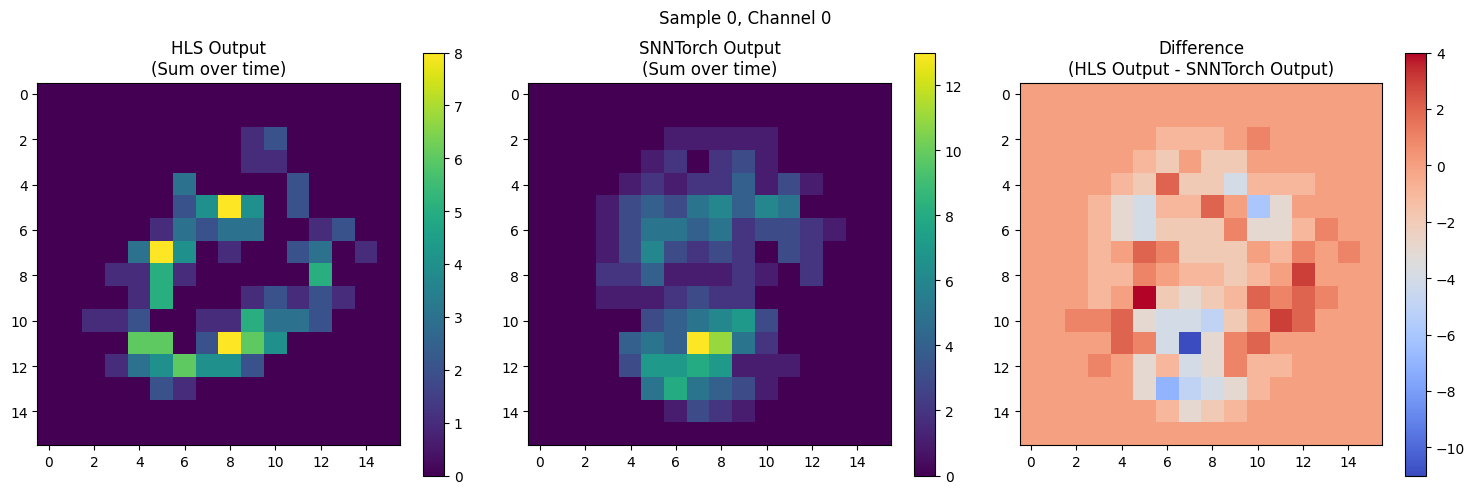

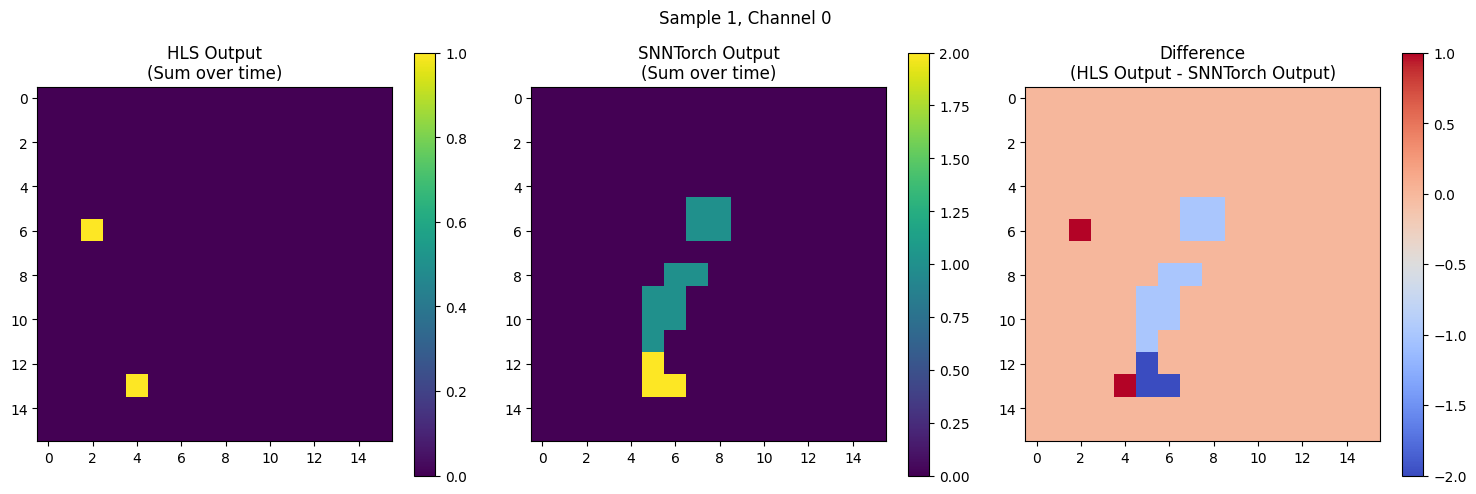

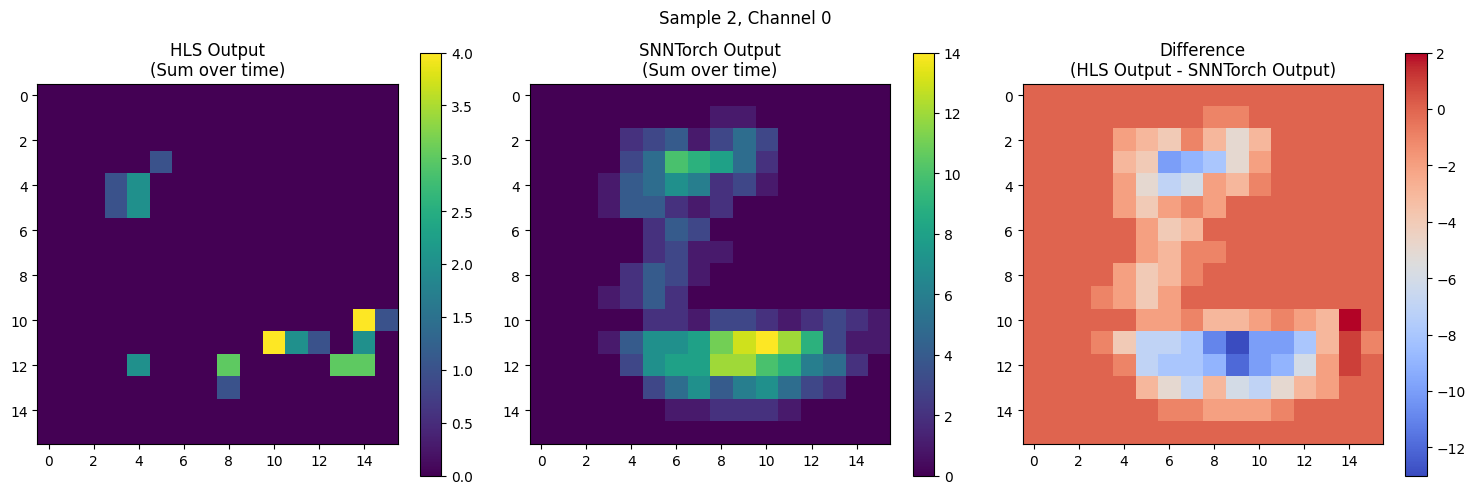

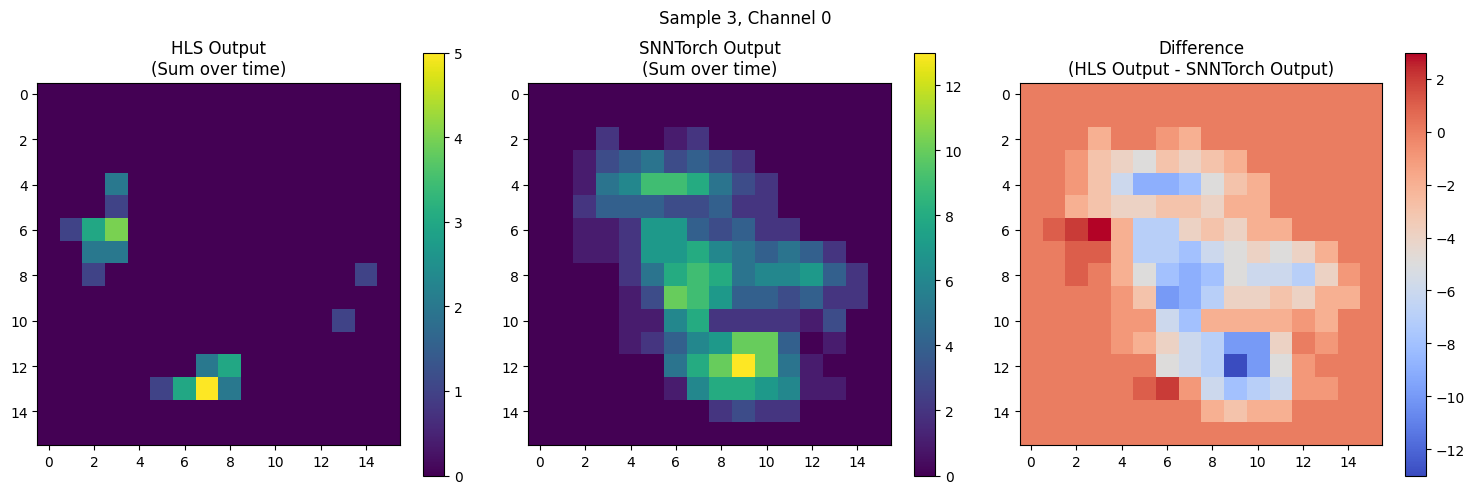

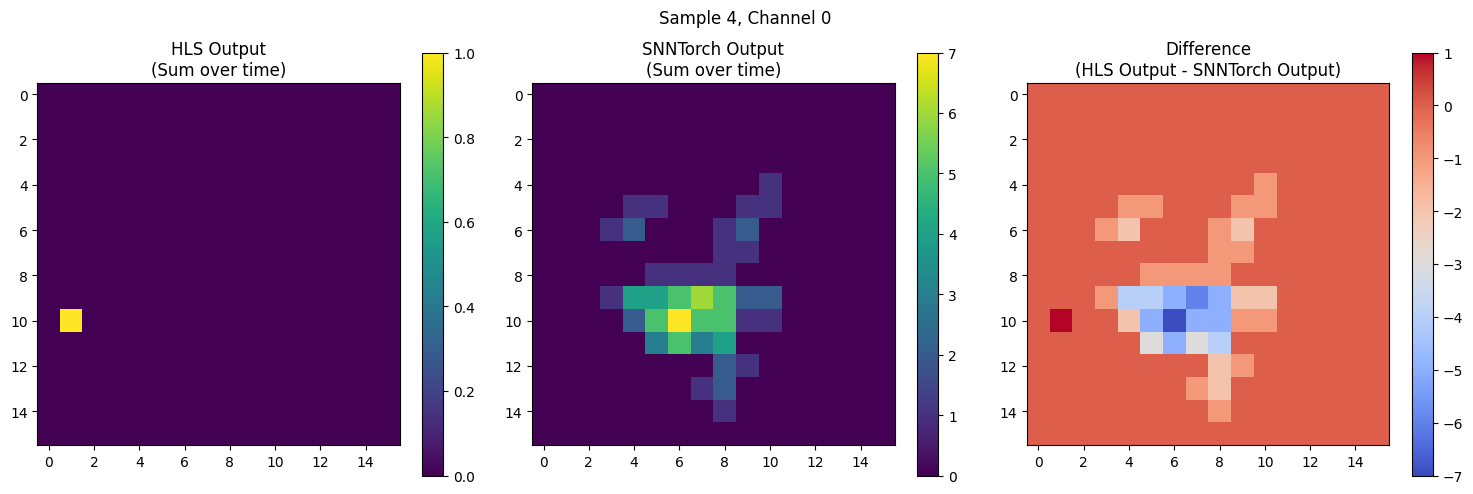

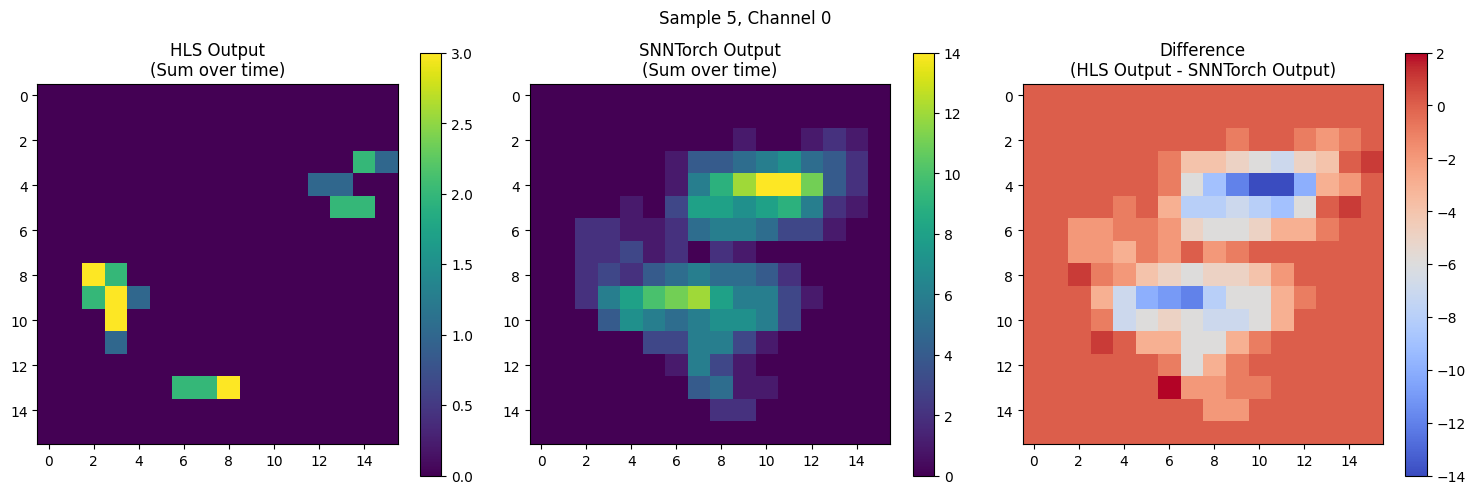

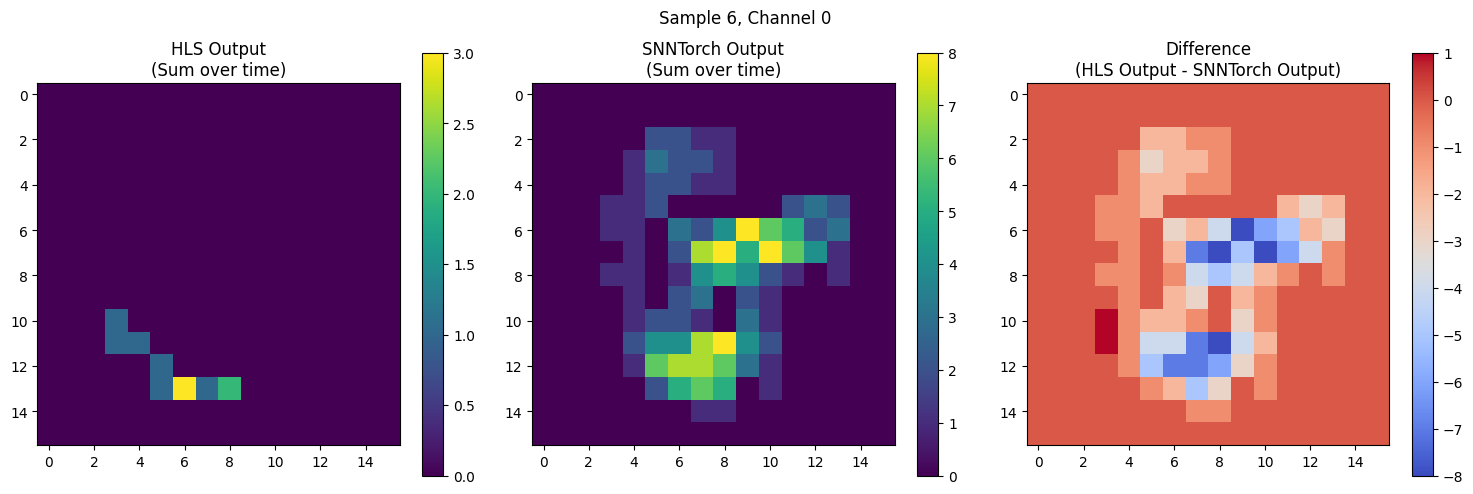

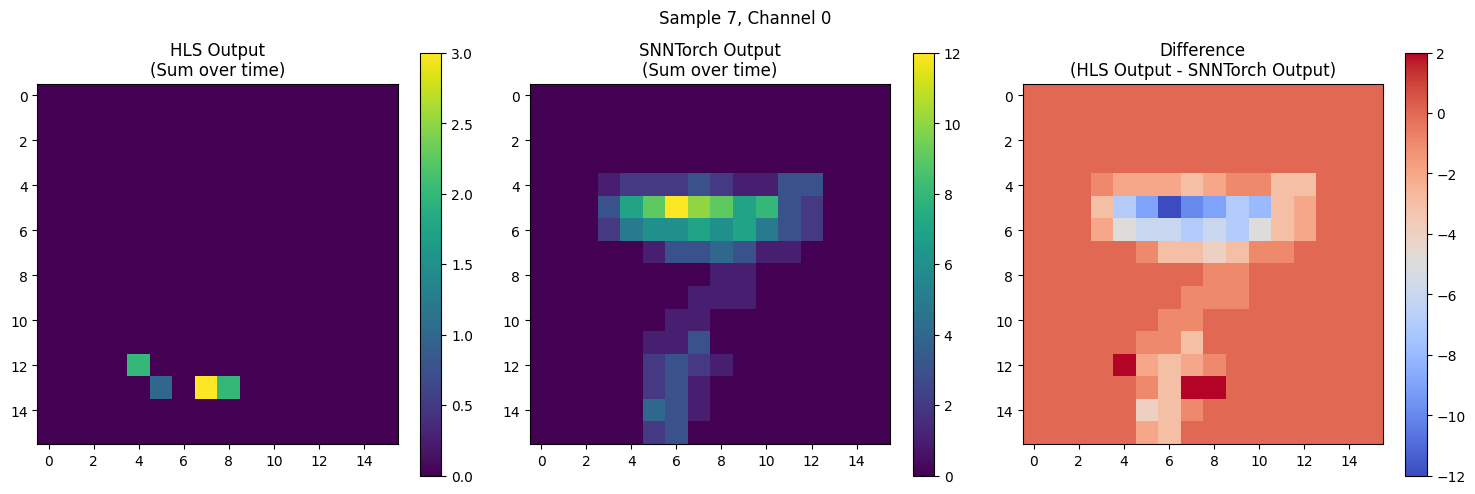

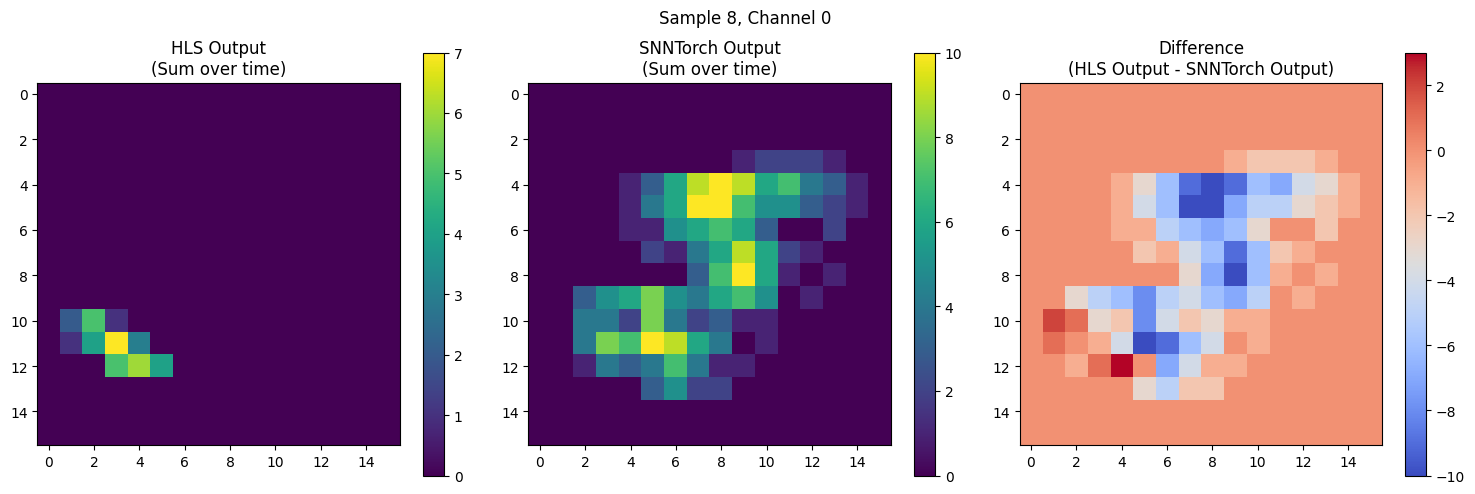

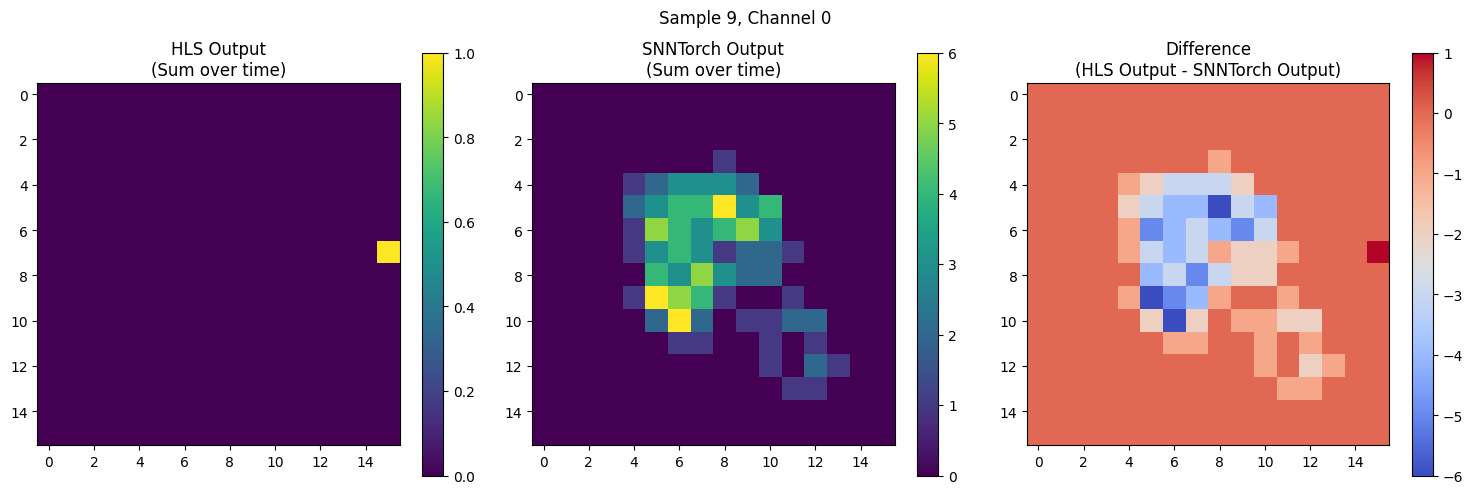

In [ ]:
import matplotlib.pyplot as plt

def visualize_comparison(t1, t2, sample_idx=0, channel_idx=0, title1="HLS Output", title2="SNNTorch Output"):
    """
    Visualiza e compara dois tensores (Time, Batch, Channel, Height, Width)
    acumulando os spikes ao longo do tempo.
    """
    if hasattr(t1, "cpu"): t1 = t1.cpu().numpy()
    if hasattr(t2, "cpu"): t2 = t2.cpu().numpy()
    
    # Seleciona sample e channel
    # Shape esperado: (T, B, C, H, W)
    # Soma ao longo do tempo (eixo 0) para obter a "imagem" de atividade
    if t1.shape[1] > sample_idx:
        img1 = t1[:, sample_idx, channel_idx, :, :].sum(axis=0)
    else:
        print(f"Sample {sample_idx} not found in HLS output")
        return

    if t2.shape[1] > sample_idx:
        img2 = t2[:, sample_idx, channel_idx, :, :].sum(axis=0)
    else:
        print(f"Sample {sample_idx} not found in SNNTorch output")
        return
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Plot Tensor 1
    im1 = axes[0].imshow(img1, cmap='viridis', interpolation='nearest')
    axes[0].set_title(f"{title1}\n(Sum over time)")
    plt.colorbar(im1, ax=axes[0])
    
    # Plot Tensor 2
    im2 = axes[1].imshow(img2, cmap='viridis', interpolation='nearest')
    axes[1].set_title(f"{title2}\n(Sum over time)")
    plt.colorbar(im2, ax=axes[1])
    
    # Plot Diferença
    diff = img1 - img2
    im3 = axes[2].imshow(diff, cmap='coolwarm', interpolation='nearest')
    axes[2].set_title(f"Difference\n({title1} - {title2})")
    plt.colorbar(im3, ax=axes[2])
    
    plt.suptitle(f"Sample {sample_idx}, Channel {channel_idx}")
    plt.tight_layout()
    plt.show()

# Detecta quantas amostras existem no tensor (assume que ambos têm o mesmo número de amostras ou usa o menor)
num_samples = min(hls_output.shape[1], snntorch_output.shape[1])

# Loop para visualizar todas as amostras
for i in range(num_samples):
    visualize_comparison(hls_output, snntorch_output, sample_idx=i, channel_idx=0)